# Notebook 05 – Détection contextualisée des anomalies

## Objectif

Ce notebook constitue le cœur de la détection d'anomalies du projet.

L'analyse est réalisée à la granularité **EAN × mois** et cherche à identifier des
comportements économiquement atypiques en tenant compte de deux références
complémentaires :

1. **le périmètre métier** : Département → Sous-département → Famille, à période
   comparable ;
2. **l'historique propre de l'EAN** : évolution de ses prix et de ses marges dans
   le temps.

La détection combine :

- des règles métier déterministes ;
- une détection d'atypie au sein des EAN comparables ;
- une détection de rupture temporelle propre à l'EAN ;
- un benchmark de méthodes non supervisées, notamment Isolation Forest et LOF.


L'objectif final est d'obtenir une anomalie **contextualisée et explicable** :

EAN × mois → règle métier / écart famille / rupture temporelle / ML
→ fusion des signaux → type d'anomalie → priorité.


In [1]:
# =============================================================================
# Import des bibliothèques
# =============================================================================

from pathlib import Path
import warnings
import time

import numpy as np
import pandas as pd

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    average_precision_score,
    roc_auc_score,
    precision_recall_curve
)

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

print("Bibliothèques chargées.")


Bibliothèques chargées.


In [7]:
# =============================================================================
# Définition des chemins
# =============================================================================

PROJECT_DIR = Path.cwd().parent

DATA_DIR = PROJECT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
RESULTS_DIR = DATA_DIR / "results"

ANOMALY_DIR = RESULTS_DIR / "anomaly_detection"

ANOMALY_DIR.mkdir(
    parents=True,
    exist_ok=True
)


In [3]:
# =============================================================================
# Chargement du dataset issu du Feature Engineering
# =============================================================================

DATASET_PATH = PROCESSED_DIR / "dataset_features.csv"

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Dataset introuvable : {DATASET_PATH}"
    )

df = pd.read_csv(
    DATASET_PATH,
    dtype={
        "EAN": "string",
        "Year": "Int64",
        "MonthLib": "string"
    }
)

print("=" * 70)
print("NOTEBOOK 06 - DETECTION CONTEXTUALISEE DES ANOMALIES")
print("=" * 70)

print(f"Observations : {len(df):,}")
print(f"Variables    : {df.shape[1]:,}")


NOTEBOOK 06 - DETECTION CONTEXTUALISEE DES ANOMALIES
Observations : 68,324
Variables    : 49


In [4]:
# =============================================================================
# Contrôles de cohérence du dataset
# =============================================================================

required_columns = [
    "EAN",
    "Year",
    "MonthLib",
    "International Department",
    "International Sub Department",
    "International Family",
    "Average Purchasing Price N",
    "Average selling price N",
    "Tx M3N MDH Inter N",
    "Tx M3N non CP N"
]

missing_required = [
    col for col in required_columns
    if col not in df.columns
]

if missing_required:
    raise ValueError(
        f"Variables nécessaires absentes : {missing_required}"
    )

print("=" * 70)
print("CONTROLES DE COHERENCE")
print("=" * 70)

print(f"EAN manquants : {df['EAN'].isna().sum():,}")
print(f"Valeurs Year manquantes : {df['Year'].isna().sum():,}")
print(f"Famille manquante : {df['International Family'].isna().sum():,}")

if df["EAN"].isna().any():
    print("des EAN sans identifiant ne peuvent pas être analysés au niveau EAN.")

print("Contrôles terminés.")


CONTROLES DE COHERENCE
EAN manquants : 0
Valeurs Year manquantes : 0
Famille manquante : 0
Contrôles terminés.


In [8]:
# =============================================================================
# Contrôle des valeurs manquantes attendues
# =============================================================================

ml_features = [
    "Price_Gap_N",
    "Price_Ratio_N",
    "Purchase_Price_Variation",
    "Selling_Price_Variation",
    "Margin_MDH_Variation",
    "Margin_Local_Variation",
    "Family_Robust_Z_Selling_Price",
    "Family_Robust_Z_Purchase_Price",
    "Family_Robust_Z_Margin_MDH",
    "Family_Robust_Z_Margin_Local",
    "Temporal_Robust_Z_Selling_Price",
    "Temporal_Robust_Z_Purchase_Price",
    "Temporal_Robust_Z_Margin_MDH",
    "Temporal_Robust_Z_Margin_Local"
]

missing_ml_features = [
    col for col in ml_features
    if col not in df.columns
]

if missing_ml_features:
    raise ValueError(
        "Variables ML manquantes dans dataset_features.csv : "
        + ", ".join(missing_ml_features)
    )

if len(ml_features) != 14:
    raise ValueError(
        f"14 variables ML sont attendues, "
        f"mais {len(ml_features)} sont définies."
    )

print("=" * 70)
print("CONTRÔLE DES VARIABLES ML")
print("=" * 70)

print(f"Nombre de variables ML : {len(ml_features)}")

for i, feature in enumerate(ml_features, start=1):
    print(f"{i:02d}. {feature}")

print("Les variables comportementales sont présentes.")

CONTRÔLE DES VARIABLES ML
Nombre de variables ML : 14
01. Price_Gap_N
02. Price_Ratio_N
03. Purchase_Price_Variation
04. Selling_Price_Variation
05. Margin_MDH_Variation
06. Margin_Local_Variation
07. Family_Robust_Z_Selling_Price
08. Family_Robust_Z_Purchase_Price
09. Family_Robust_Z_Margin_MDH
10. Family_Robust_Z_Margin_Local
11. Temporal_Robust_Z_Selling_Price
12. Temporal_Robust_Z_Purchase_Price
13. Temporal_Robust_Z_Margin_MDH
14. Temporal_Robust_Z_Margin_Local
Les variables comportementales sont présentes.


## Partie 2 — Règles métier

Les règles métier constituent le premier niveau de contrôle.

Elles détectent des incohérences économiques explicites, indépendamment des
modèles statistiques :

- prix d'achat ou de vente négatif ;
- prix de vente inférieur au prix d'achat lorsque les deux valeurs sont disponibles ;
- marge internationale négative ou supérieure à 100 % ;
- marge locale négative ou supérieure à 100 %.


In [9]:
# =============================================================================
# Paramètres des règles métier
# =============================================================================
#
# Ces règles correspondent à des incohérences métier intrinsèques.
#
# Une violation d'au moins une règle entraîne une classification CRITIQUE.
# =============================================================================

MARGIN_MIN = 0
MARGIN_MAX = 100

print("=" * 70)
print("PARAMETRES DES REGLES METIER")
print("=" * 70)

print(f"Marge minimale autorisée : {MARGIN_MIN}%")
print(f"Marge maximale autorisée : {MARGIN_MAX}%")

PARAMETRES DES REGLES METIER
Marge minimale autorisée : 0%
Marge maximale autorisée : 100%


In [11]:
# =============================================================================
# Application des règles métier
# =============================================================================
#
# Une observation est considérée comme présentant une anomalie métier
# dès qu'au moins une règle de cohérence est enfreinte.
#
# =============================================================================

df_anomaly = df.copy()


# =============================================================================
# RÈGLE 1 - Prix d'achat négatif
# =============================================================================

df_anomaly["Rule_Negative_Purchase_Price"] = (
    df_anomaly["Average Purchasing Price N"] < 0
)


# =============================================================================
# RÈGLE 2 - Prix de vente négatif
# =============================================================================

df_anomaly["Rule_Negative_Selling_Price"] = (
    df_anomaly["Average selling price N"] < 0
)


# =============================================================================
# RÈGLE 3 - Prix de vente inférieur au prix d'achat
# =============================================================================

df_anomaly["Rule_Selling_Below_Purchase"] = (
    df_anomaly["Average selling price N"].notna()
    &
    df_anomaly["Average Purchasing Price N"].notna()
    &
    (
        df_anomaly["Average selling price N"]
        <
        df_anomaly["Average Purchasing Price N"]
    )
)


# =============================================================================
# RÈGLE 4 - Marge internationale négative
# =============================================================================

df_anomaly["Rule_Negative_Margin_MDH"] = (
    df_anomaly["Tx M3N MDH Inter N"] < MARGIN_MIN
)


# =============================================================================
# RÈGLE 5 - Marge locale négative
# =============================================================================

df_anomaly["Rule_Negative_Margin_Local"] = (
    df_anomaly["Tx M3N non CP N"] < MARGIN_MIN
)


# =============================================================================
# RÈGLE 6 - Marge internationale supérieure à 100 %
# =============================================================================

df_anomaly["Rule_Margin_MDH_Above_100"] = (
    df_anomaly["Tx M3N MDH Inter N"] > MARGIN_MAX
)


# =============================================================================
# RÈGLE 7 - Marge locale supérieure à 100 %
# =============================================================================

df_anomaly["Rule_Margin_Local_Above_100"] = (
    df_anomaly["Tx M3N non CP N"] > MARGIN_MAX
)


# =============================================================================
# AGRÉGATION DES RÈGLES MÉTIER
# =============================================================================

rule_columns = [
    "Rule_Negative_Purchase_Price",
    "Rule_Negative_Selling_Price",
    "Rule_Selling_Below_Purchase",
    "Rule_Negative_Margin_MDH",
    "Rule_Negative_Margin_Local",
    "Rule_Margin_MDH_Above_100",
    "Rule_Margin_Local_Above_100"
]


df_anomaly["Business_Rule_Anomaly"] = (
    df_anomaly[rule_columns]
    .any(axis=1)
)


print("=" * 70)
print("RÈGLES MÉTIER")
print("=" * 70)

print(
    f"Observations avec violation métier : "
    f"{int(df_anomaly['Business_Rule_Anomaly'].sum()):,}"
)


display(
    df_anomaly[
        [
            "EAN",
            "Business_Rule_Anomaly"
        ]
    ].head()
)

RÈGLES MÉTIER
Observations avec violation métier : 1,663


,EAN,Business_Rule_Anomaly
0,3014627554317,True
1,3014627554317,True
2,3014627554324,False
3,3014627554324,False
4,3014627554324,False


In [12]:
# =============================================================================
# Raisons des violations des règles métier
# =============================================================================

rule_labels = {

    "Rule_Selling_Below_Purchase":
        "Prix de vente inférieur au prix d'achat",

    "Rule_Negative_Margin_Local":
        "Marge locale négative",

    "Rule_Negative_Margin_MDH":
        "Marge internationale négative",

    "Rule_Negative_Selling_Price":
        "Prix de vente négatif",

    "Rule_Negative_Purchase_Price":
        "Prix d'achat négatif",

    "Rule_Margin_Local_Above_100":
        "Marge locale supérieure à 100 %",

    "Rule_Margin_MDH_Above_100":
        "Marge internationale supérieure à 100 %"

}


def build_business_rule_reason(row):

    detected_rules = [

        label

        for column, label in rule_labels.items()

        if bool(row[column])

    ]

    return (
        " | ".join(detected_rules)
        if detected_rules
        else None
    )


df_anomaly["Business_Rule_Reason"] = (

    df_anomaly
    .apply(
        build_business_rule_reason,
        axis=1
    )

)

display(
    df_anomaly[
        [
            "EAN",
            "Business_Rule_Anomaly",
            "Business_Rule_Reason"
        ]
    ]
    .loc[
        df_anomaly["Business_Rule_Anomaly"]
    ]
    .head(10)
)

,EAN,Business_Rule_Anomaly,Business_Rule_Reason
0,3014627554317,True,Prix de vente inférieur au prix d'achat | Marg...
1,3014627554317,True,Prix de vente inférieur au prix d'achat | Marg...
52,3014627830039,True,Prix de vente inférieur au prix d'achat | Marg...
93,3014627874491,True,Prix de vente inférieur au prix d'achat | Marg...
320,3014627943913,True,Prix de vente inférieur au prix d'achat | Marg...
466,3014627974184,True,Marge locale supérieure à 100 %
477,3031520172943,True,Prix de vente inférieur au prix d'achat | Marg...
491,3031520172950,True,Prix de vente inférieur au prix d'achat | Marg...
507,3031520262583,True,Prix de vente inférieur au prix d'achat | Marg...
518,3031520262613,True,Prix de vente inférieur au prix d'achat | Marg...


## Partie 3 — Analyse contextuelle au sein de la famille

Une anomalie ne doit pas être évaluée uniquement par rapport à l'ensemble des
produits.

La comparaison est réalisée au même mois et dans le même périmètre :

**Département → Sous-département → Famille**

Pour chaque variable économique, on calcule une médiane et une dispersion
robuste (MAD) au niveau des produits comparables. Un score robuste élevé indique
qu'un EAN est éloigné du comportement habituel de sa famille sur la période.


In [14]:
# =============================================================================
# Contrôle des variables familiales utilisées par le ML
# =============================================================================

family_features = [
    "Family_Robust_Z_Selling_Price",
    "Family_Robust_Z_Purchase_Price",
    "Family_Robust_Z_Margin_MDH",
    "Family_Robust_Z_Margin_Local"
]

missing_family_features = [
    c for c in family_features
    if c not in df_anomaly.columns
]

if missing_family_features:
    raise ValueError(
        "Variables familiales absentes de df_anomaly : "
        + ", ".join(missing_family_features)
    )

print("=" * 70)
print("VARIABLES FAMILIALES")
print("=" * 70)

print(f"Nombre de variables familiales : {len(family_features)}")

for i, feature in enumerate(family_features, start=1):
    print(f"{i:02d}. {feature}")

print("Les variables familiales sont présentes.")

VARIABLES FAMILIALES
Nombre de variables familiales : 4
01. Family_Robust_Z_Selling_Price
02. Family_Robust_Z_Purchase_Price
03. Family_Robust_Z_Margin_MDH
04. Family_Robust_Z_Margin_Local
Les variables familiales sont présentes.


## Partie 4 — Analyse temporelle du comportement propre à l'EAN

Le deuxième axe de contextualisation consiste à comparer chaque observation
à l'historique disponible du même EAN.


In [16]:
# Contrôle des variables temporelles utilisées par le ML

temporal_features = [
    "Temporal_Robust_Z_Selling_Price",
    "Temporal_Robust_Z_Purchase_Price",
    "Temporal_Robust_Z_Margin_MDH",
    "Temporal_Robust_Z_Margin_Local"
]

missing_temporal_features = [
    c for c in temporal_features
    if c not in df_anomaly.columns
]

if missing_temporal_features:
    raise ValueError(
        "Variables temporelles absentes de df_anomaly : "
        + ", ".join(missing_temporal_features)
    )

print("=" * 70)
print("VARIABLES TEMPORELLES")
print("=" * 70)

print(f"Nombre de variables temporelles : {len(temporal_features)}")

for i, feature in enumerate(temporal_features, start=1):
    print(f"{i:02d}. {feature}")

print("Les variables temporelles sont présentes.")

VARIABLES TEMPORELLES
Nombre de variables temporelles : 4
01. Temporal_Robust_Z_Selling_Price
02. Temporal_Robust_Z_Purchase_Price
03. Temporal_Robust_Z_Margin_MDH
04. Temporal_Robust_Z_Margin_Local
Les variables temporelles sont présentes.


## Partie 5 — Détection non supervisée par Machine Learning

Le Machine Learning intervient comme un signal complémentaire.

La matrice d'apprentissage combine :

- évolutions de prix et de marges ;
- écarts robustes aux EAN comparables ;
- écarts robustes à l'historique propre de l'EAN ;
- quelques indicateurs économiques courants.


In [17]:
# =============================================================================
# Préparation de la population destinée au Machine Learning
# =============================================================================
#
# Le Machine Learning utilise uniquement des variables quantitatives
# décrivant le comportement économique des EAN.
#
# Les Robust Z familiaux et temporels sont utilisés comme variables
# quantitatives.
# =============================================================================

ml_features = [

    # -------------------------------------------------------------------------
    # Niveau économique courant
    # -------------------------------------------------------------------------
    "Price_Gap_N",
    "Price_Ratio_N",

    # -------------------------------------------------------------------------
    # Evolution N / N-1
    # -------------------------------------------------------------------------
    "Purchase_Price_Variation",
    "Selling_Price_Variation",
    "Margin_MDH_Variation",
    "Margin_Local_Variation",

    # -------------------------------------------------------------------------
    # Positionnement familial
    # -------------------------------------------------------------------------
    "Family_Robust_Z_Selling_Price",
    "Family_Robust_Z_Purchase_Price",
    "Family_Robust_Z_Margin_MDH",
    "Family_Robust_Z_Margin_Local",

    # -------------------------------------------------------------------------
    # Positionnement historique
    # -------------------------------------------------------------------------
    "Temporal_Robust_Z_Selling_Price",
    "Temporal_Robust_Z_Purchase_Price",
    "Temporal_Robust_Z_Margin_MDH",
    "Temporal_Robust_Z_Margin_Local"

]

missing_ml_features = [
    column
    for column in ml_features
    if column not in df_anomaly.columns
]

if missing_ml_features:
    raise ValueError(
        f"Variables ML absentes : {missing_ml_features}"
    )

print("=" * 70)
print("VARIABLES RETENUES POUR LE MACHINE LEARNING")
print("=" * 70)

print(
    f"Nombre de variables ML : {len(ml_features)}"
)

display(
    pd.DataFrame({
        "Index": range(1, len(ml_features) + 1),
        "Variable": ml_features
    })
)

VARIABLES RETENUES POUR LE MACHINE LEARNING
Nombre de variables ML : 14


,Index,Variable
0,1,Price_Gap_N
1,2,Price_Ratio_N
2,3,Purchase_Price_Variation
3,4,Selling_Price_Variation
4,5,Margin_MDH_Variation
5,6,Margin_Local_Variation
6,7,Family_Robust_Z_Selling_Price
7,8,Family_Robust_Z_Purchase_Price
8,9,Family_Robust_Z_Margin_MDH
9,10,Family_Robust_Z_Margin_Local


In [18]:
# Construction de la matrice comportementale

X = df_anomaly[ml_features].copy()

assert X.shape[1] == 14
print(f"Matrice ML : {X.shape[0]:,} observations × {X.shape[1]} variables")


Matrice ML : 68,324 observations × 14 variables


In [19]:
# Imputation médiane des variables ML

imputer = SimpleImputer(strategy="median")
X_anomaly_model = pd.DataFrame(
    imputer.fit_transform(X),
    columns=ml_features,
    index=X.index
)

assert not X_anomaly_model.isna().any().any()
print("Imputation médiane terminée :", X_anomaly_model.shape)


Imputation médiane terminée : (68324, 14)


In [20]:
# Préparation spécifique aux deux méthodes

X_IF = X_anomaly_model.copy()

lof_scaler = RobustScaler()
X_LOF = pd.DataFrame(
    lof_scaler.fit_transform(X_anomaly_model),
    columns=ml_features,
    index=X_anomaly_model.index
)

print("Isolation Forest :", X_IF.shape)
print("LOF (RobustScaler) :", X_LOF.shape)


Isolation Forest : (68324, 14)
LOF (RobustScaler) : (68324, 14)


## Partie 6 — Benchmark Isolation Forest et LOF

Deux méthodes non supervisées complémentaires sont comparées :

- **Isolation Forest** 
- **LOF (Local Outlier Factor)**

Les deux méthodes sont appliquées à l'ensemble de la population analysée.

Le Machine Learning produit un **score continu d'atypie**. 

Le benchmark vise à comparer les méthodes selon leur capacité à classer les observations synthétiquement perturbées parmi les observations les plus atypiques, ainsi que selon la stabilité des résultats.

In [21]:
# =============================================================================
# PARAMÈTRES DU BENCHMARK
# =============================================================================

IF_N_ESTIMATORS_VALUES = [
    100,
    300,
    500
]

LOF_N_NEIGHBORS_VALUES = [
    50,
    75,
    100,
    125
]

BENCHMARK_SEEDS = [
    42,
    52,
    62,
    72
]

print("=" * 70)
print("PARAMÈTRES DU BENCHMARK")
print("=" * 70)

print(
    f"Isolation Forest - n_estimators : "
    f"{IF_N_ESTIMATORS_VALUES}"
)

print(
    f"LOF - n_neighbors : "
    f"{LOF_N_NEIGHBORS_VALUES}"
)

print(
    f"Seeds : "
    f"{BENCHMARK_SEEDS}"
)

PARAMÈTRES DU BENCHMARK
Isolation Forest - n_estimators : [100, 300, 500]
LOF - n_neighbors : [50, 75, 100, 125]
Seeds : [42, 52, 62, 72]


In [22]:
# =============================================================================
# FONCTIONS DE SCORE
# =============================================================================

def isolation_forest_score(model, X_data):
    """
    Score d'atypie Isolation Forest.
    Plus le score est élevé, plus l'observation est atypique.
    """
    return -model.score_samples(X_data)


def lof_score(model, X_data):
    """
    Score d'atypie LOF.
    Plus le score est élevé, plus l'observation est atypique.
    """
    return -model.score_samples(X_data)

## Partie 7 — Validation expérimentale contrôlée

Les données réelles ne disposent pas d'un étiquetage exhaustif des anomalies.
Une validation synthétique complémentaire est donc utilisée.

Des perturbations contrôlées sont injectées dans les variables comportementales
du jeu de validation afin de mesurer la capacité des modèles à retrouver des
anomalies connues.


In [23]:
# =============================================================================
# PROTOCOLE DE VALIDATION MULTI-SCÉNARIOS ET MULTI-SEEDS
# =============================================================================
#
# Les anomalies synthétiques sont générées avec plusieurs amplitudes
# de perturbation Z.
#
# Z représente ici l'intensité de la perturbation artificielle.
# =============================================================================

VALIDATION_SIZE = min(
    2000,
    max(500, len(X_anomaly_model) // 10)
)

ANOMALY_RATE = 0.10

VALIDATION_SEEDS = [
    42,
    52,
    62,
    72
]

Z_VALUES = [
    2.5,
    3.0,
    3.5,
    4.0,
    4.5
]

SCENARIOS = [
    "Famille",
    "Temporel",
    "Famille + Temporel"
]

In [24]:
# =============================================================================
# GÉNÉRATION DES VALIDATIONS SYNTHÉTIQUES
# =============================================================================
#
# Pour chaque seed et chaque niveau de perturbation Z, un jeu de validation
# est construit à partir du même échantillon d'observations normales.
#
# Les anomalies synthétiques sont réparties entre les trois scénarios :
# - Famille ;
# - Temporel ;
# - Famille + Temporel.
#
# =============================================================================

scenario_features = {

    "Famille": [
        "Family_Robust_Z_Margin_MDH",
        "Family_Robust_Z_Margin_Local"
    ],

    "Temporel": [
        "Temporal_Robust_Z_Margin_MDH",
        "Temporal_Robust_Z_Margin_Local",
        "Temporal_Robust_Z_Selling_Price"
    ],

    "Famille + Temporel": [
        "Family_Robust_Z_Margin_MDH",
        "Temporal_Robust_Z_Margin_MDH",
        "Family_Robust_Z_Selling_Price",
        "Temporal_Robust_Z_Selling_Price"
    ]
}


validation_experiments = []


for seed in VALIDATION_SEEDS:

    rng = np.random.default_rng(seed)

    # -------------------------------------------------------------------------
    # Jeu de validation et jeu d'entraînement
    # -------------------------------------------------------------------------

    validation_indices = X_anomaly_model.sample(
        n=VALIDATION_SIZE,
        random_state=seed
    ).index

    X_validation_normal = X_anomaly_model.loc[
        validation_indices
    ].copy()

    X_train_validation = X_anomaly_model.drop(
        index=validation_indices
    ).copy()

    # -------------------------------------------------------------------------
    # Nombre d'anomalies synthétiques
    # -------------------------------------------------------------------------

    n_anomalies = int(
        len(X_validation_normal) * ANOMALY_RATE
    )

    n_each = n_anomalies // len(SCENARIOS)

    for Z_SYNTHETIC in Z_VALUES:

        # ---------------------------------------------------------------------
        # Sélection des observations à perturber
        # ---------------------------------------------------------------------

        indices = rng.choice(
            X_validation_normal.index,
            size=n_anomalies,
            replace=False
        )

        scenario_indices = {
            "Famille": indices[:n_each],
            "Temporel": indices[n_each:2 * n_each],
            "Famille + Temporel": indices[2 * n_each:]
        }

        # ---------------------------------------------------------------------
        # Jeu de validation
        # ---------------------------------------------------------------------

        X_validation = X_validation_normal.copy()

        y_validation = pd.Series(
            False,
            index=X_validation.index,
            dtype=bool
        )

        validation_type = pd.Series(
            "Non perturbée",
            index=X_validation.index,
            dtype="string"
        )

        # ---------------------------------------------------------------------
        # Injection des anomalies synthétiques
        # ---------------------------------------------------------------------

        for scenario in SCENARIOS:

            idx = scenario_indices[scenario]

            for feature in scenario_features[scenario]:

                direction = np.where(
                    rng.random(len(idx)) < 0.5,
                    -1,
                    1
                )

                X_validation.loc[idx, feature] = (
                    direction * Z_SYNTHETIC
                )

            y_validation.loc[idx] = True

            validation_type.loc[idx] = scenario

        # ---------------------------------------------------------------------
        # Conservation de l'expérience
        # ---------------------------------------------------------------------

        validation_experiments.append({
            "seed": seed,
            "Z": Z_SYNTHETIC,
            "X_train": X_train_validation.copy(),
            "X_validation": X_validation.copy(),
            "y_validation": y_validation.copy(),
            "validation_type": validation_type.copy()
        })


# -----------------------------------------------------------------------------
# Contrôle 
# -----------------------------------------------------------------------------

expected_experiments = (
    len(VALIDATION_SEEDS) * len(Z_VALUES)
)

assert len(validation_experiments) == expected_experiments

print(
    f"Validations synthétiques générées : "
    f"{len(validation_experiments)}"
)

Validations synthétiques générées : 20


In [25]:
# =============================================================================
# VALIDATION DES CONFIGURATIONS
# =============================================================================
#
# Chaque configuration est évaluée sur l'ensemble du jeu de validation
# synthétique.
#
# Les modèles produisent un score continu d'atypie.
#
# Les performances sont évaluées avec :
# - Average Precision (AP) ;
# - ROC-AUC.
#
# Ces deux métriques sont calculées directement à partir des scores continus
# produits par les modèles. 
#
# Les anomalies synthétiques constituent les labels de référence.
#
# Chaque configuration est testée sur :
# - plusieurs seeds ;
# - plusieurs niveaux de perturbation Z ;
# - plusieurs scénarios d'anomalie.
# =============================================================================


from sklearn.metrics import (
    average_precision_score,
    roc_auc_score
)


validation_results = []


# =============================================================================
# 1. Boucle principale sur les seeds
# =============================================================================

for seed in VALIDATION_SEEDS:

    seed_experiments = [
        exp
        for exp in validation_experiments
        if exp["seed"] == seed
    ]

    if not seed_experiments:
        continue

    X_train_validation = seed_experiments[0]["X_train"].copy()


    # =========================================================================
    # 2. ISOLATION FOREST
    # =========================================================================

    for n_estimators in IF_N_ESTIMATORS_VALUES:

        model_if = IsolationForest(
            n_estimators=n_estimators,
            contamination="auto",
            max_samples="auto",
            max_features=1.0,
            random_state=seed,
            n_jobs=-1
        )

        model_if.fit(
            X_train_validation
        )


        for experiment in seed_experiments:

            Z = experiment["Z"]

            X_validation = experiment["X_validation"]
            y_validation = experiment["y_validation"]
            validation_type = experiment["validation_type"]


            # -----------------------------------------------------------------
            # Score continu
            # -----------------------------------------------------------------

            scores = isolation_forest_score(
                model_if,
                X_validation
            )


            # -----------------------------------------------------------------
            # Évaluation globale
            # -----------------------------------------------------------------

            validation_results.append({

                "Seed": seed,

                "Z": Z,

                "Scenario": "Global",

                "Methode": "Isolation Forest",

                "Parametres": (
                    f"trees={n_estimators}"
                ),

                "Average_Precision": (
                    average_precision_score(
                        y_validation,
                        scores
                    )
                ),

                "ROC_AUC": (
                    roc_auc_score(
                        y_validation,
                        scores
                    )
                )
            })


            # -----------------------------------------------------------------
            # Évaluation par scénario
            # -----------------------------------------------------------------

            for scenario in SCENARIOS:

                scenario_mask = (
                    (validation_type == "Non perturbée")
                    |
                    (validation_type == scenario)
                )


                y_scenario = (
                    validation_type.loc[
                        scenario_mask
                    ] == scenario
                )


                scores_scenario = np.asarray(
                    scores
                )[scenario_mask.to_numpy()]


                validation_results.append({

                    "Seed": seed,

                    "Z": Z,

                    "Scenario": scenario,

                    "Methode": "Isolation Forest",

                    "Parametres": (
                        f"trees={n_estimators}"
                    ),

                    "Average_Precision": (
                        average_precision_score(
                            y_scenario,
                            scores_scenario
                        )
                    ),

                    "ROC_AUC": (
                        roc_auc_score(
                            y_scenario,
                            scores_scenario
                        )
                    )
                })


    # =========================================================================
    # 3. LOF
    # =========================================================================

    validation_scaler = RobustScaler()

    X_train_scaled = pd.DataFrame(
        validation_scaler.fit_transform(
            X_train_validation
        ),
        columns=ml_features,
        index=X_train_validation.index
    )


    for n_neighbors in LOF_N_NEIGHBORS_VALUES:

        model_lof = LocalOutlierFactor(
            n_neighbors=n_neighbors,
            novelty=True,
            n_jobs=-1
        )

        model_lof.fit(
            X_train_scaled
        )


        for experiment in seed_experiments:

            Z = experiment["Z"]

            X_validation = experiment["X_validation"]
            y_validation = experiment["y_validation"]
            validation_type = experiment["validation_type"]


            # -----------------------------------------------------------------
            # Mise à l'échelle du jeu de validation
            # avec le scaler appris sur le train
            # -----------------------------------------------------------------

            X_validation_scaled = pd.DataFrame(
                validation_scaler.transform(
                    X_validation
                ),
                columns=ml_features,
                index=X_validation.index
            )


            # -----------------------------------------------------------------
            # Score continu
            # -----------------------------------------------------------------

            scores = lof_score(
                model_lof,
                X_validation_scaled
            )


            # -----------------------------------------------------------------
            # Évaluation globale
            # -----------------------------------------------------------------

            validation_results.append({

                "Seed": seed,

                "Z": Z,

                "Scenario": "Global",

                "Methode": "LOF",

                "Parametres": (
                    f"neighbors={n_neighbors}"
                ),

                "Average_Precision": (
                    average_precision_score(
                        y_validation,
                        scores
                    )
                ),

                "ROC_AUC": (
                    roc_auc_score(
                        y_validation,
                        scores
                    )
                )
            })


            # -----------------------------------------------------------------
            # Évaluation par scénario
            # -----------------------------------------------------------------

            for scenario in SCENARIOS:

                scenario_mask = (
                    (validation_type == "Non perturbée")
                    |
                    (validation_type == scenario)
                )


                y_scenario = (
                    validation_type.loc[
                        scenario_mask
                    ] == scenario
                )


                scores_scenario = np.asarray(
                    scores
                )[scenario_mask.to_numpy()]


                validation_results.append({

                    "Seed": seed,

                    "Z": Z,

                    "Scenario": scenario,

                    "Methode": "LOF",

                    "Parametres": (
                        f"neighbors={n_neighbors}"
                    ),

                    "Average_Precision": (
                        average_precision_score(
                            y_scenario,
                            scores_scenario
                        )
                    ),

                    "ROC_AUC": (
                        roc_auc_score(
                            y_scenario,
                            scores_scenario
                        )
                    )
                })


# =============================================================================
# 4. Tableau de validation
# =============================================================================

validation_metrics = pd.DataFrame(
    validation_results
)


print("=" * 70)
print("VALIDATION TERMINÉE")
print("=" * 70)

print(
    f"Nombre de résultats : "
    f"{len(validation_metrics):,}"
)


display(
    validation_metrics.head().round(3)
)

VALIDATION TERMINÉE
Nombre de résultats : 560


,Seed,Z,Scenario,Methode,Parametres,Average_Precision,ROC_AUC
0,42,2.5,Global,Isolation Forest,trees=100,0.199,0.764
1,42,2.5,Famille,Isolation Forest,trees=100,0.092,0.833
2,42,2.5,Temporel,Isolation Forest,trees=100,0.039,0.573
3,42,2.5,Famille + Temporel,Isolation Forest,trees=100,0.131,0.882
4,42,3.0,Global,Isolation Forest,trees=100,0.223,0.788


In [26]:
# =============================================================================
# SYNTHÈSE DES PERFORMANCES
# =============================================================================
#
# Les résultats sont agrégés sur l'ensemble des expériences de validation.
#
# Chaque configuration dispose de :
# - 4 seeds ;
# - 5 niveaux de Z ;
# soit 20 expériences.
#
# L'Average Precision constitue le critère principal de comparaison.
# La ROC-AUC constitue un critère complémentaire.
# =============================================================================


global_results = validation_metrics[
    validation_metrics["Scenario"] == "Global"
].copy()


summary_global = (
    global_results
    .groupby(
        [
            "Methode",
            "Parametres"
        ],
        as_index=False
    )
    .agg(

        Average_Precision_Moyenne=(
            "Average_Precision",
            "mean"
        ),

        Average_Precision_Ecart_Type=(
            "Average_Precision",
            "std"
        ),

        ROC_AUC_Moyenne=(
            "ROC_AUC",
            "mean"
        ),

        ROC_AUC_Ecart_Type=(
            "ROC_AUC",
            "std"
        ),

        Nombre_Experiences=(
            "Average_Precision",
            "count"
        )
    )
)


print("=" * 70)
print("SYNTHÈSE DES PERFORMANCES")
print("=" * 70)


display(
    summary_global
    .sort_values(
        "Average_Precision_Moyenne",
        ascending=False
    )
    .round(3)
)

SYNTHÈSE DES PERFORMANCES


,Methode,Parametres,Average_Precision_Moyenne,Average_Precision_Ecart_Type,ROC_AUC_Moyenne,ROC_AUC_Ecart_Type,Nombre_Experiences
5,LOF,neighbors=50,0.587,0.078,0.900,0.025,20
6,LOF,neighbors=75,0.552,0.077,0.890,0.025,20
3,LOF,neighbors=100,0.523,0.076,0.882,0.024,20
4,LOF,neighbors=125,0.496,0.074,0.875,0.024,20
1,Isolation Forest,trees=300,0.250,0.031,0.817,0.027,20
0,Isolation Forest,trees=100,0.250,0.031,0.812,0.028,20
2,Isolation Forest,trees=500,0.248,0.029,0.816,0.025,20


In [27]:
# =============================================================================
# MEILLEURE CONFIGURATION DE CHAQUE MÉTHODE
# =============================================================================
#
# La configuration retenue pour chaque méthode est celle qui obtient
# la meilleure Average Precision moyenne sur l'ensemble des expériences.
# =============================================================================


best_configurations = (
    summary_global
    .sort_values(
        [
            "Methode",
            "Average_Precision_Moyenne"
        ],
        ascending=[
            True,
            False
        ]
    )
    .groupby(
        "Methode",
        as_index=False
    )
    .first()
)


print("=" * 70)
print("MEILLEURE CONFIGURATION DE CHAQUE MÉTHODE")
print("=" * 70)

display(
    best_configurations[
        [
            "Methode",
            "Parametres",
            "Average_Precision_Moyenne",
            "Average_Precision_Ecart_Type",
            "ROC_AUC_Moyenne",
            "ROC_AUC_Ecart_Type",
            "Nombre_Experiences"
        ]
    ].round(3)
)

MEILLEURE CONFIGURATION DE CHAQUE MÉTHODE


,Methode,Parametres,Average_Precision_Moyenne,Average_Precision_Ecart_Type,ROC_AUC_Moyenne,ROC_AUC_Ecart_Type,Nombre_Experiences
0,Isolation Forest,trees=300,0.250,0.031,0.817,0.027,20
1,LOF,neighbors=50,0.587,0.078,0.900,0.025,20


In [28]:
# =============================================================================
# PERFORMANCE DES MEILLEURES CONFIGURATIONS PAR SCÉNARIO
# =============================================================================
#
# Après sélection de la meilleure configuration de chaque méthode sur
# l'ensemble de la validation, les performances sont analysées séparément
# selon les trois scénarios synthétiques :
#
# - Famille
# - Temporel
# - Famille + Temporel
#
# Cette analyse permet d'identifier les types de perturbations auxquels chaque méthode
# est la plus sensible.
# =============================================================================


scenario_results = validation_metrics[
    validation_metrics["Scenario"].isin(SCENARIOS)
].copy()


best_scenario_results = scenario_results.merge(
    best_configurations[
        [
            "Methode",
            "Parametres"
        ]
    ],
    on=[
        "Methode",
        "Parametres"
    ],
    how="inner"
)


scenario_summary = (
    best_scenario_results
    .groupby(
        [
            "Methode",
            "Scenario"
        ],
        as_index=False
    )
    .agg(

        Average_Precision_Moyenne=(
            "Average_Precision",
            "mean"
        ),

        Average_Precision_Ecart_Type=(
            "Average_Precision",
            "std"
        ),

        ROC_AUC_Moyenne=(
            "ROC_AUC",
            "mean"
        ),

        ROC_AUC_Ecart_Type=(
            "ROC_AUC",
            "std"
        ),

        Nombre_Experiences=(
            "Average_Precision",
            "count"
        )
    )
)


print("=" * 70)
print("PERFORMANCE DES MEILLEURES CONFIGURATIONS PAR SCÉNARIO")
print("=" * 70)

display(
    scenario_summary.round(3)
)

PERFORMANCE DES MEILLEURES CONFIGURATIONS PAR SCÉNARIO


,Methode,Scenario,Average_Precision_Moyenne,Average_Precision_Ecart_Type,ROC_AUC_Moyenne,ROC_AUC_Ecart_Type,Nombre_Experiences
0,Isolation Forest,Famille,0.131,0.021,0.882,0.022,20
1,Isolation Forest,Famille + Temporel,0.159,0.035,0.903,0.025,20
2,Isolation Forest,Temporel,0.051,0.005,0.663,0.038,20
3,LOF,Famille,0.447,0.096,0.890,0.036,20
4,LOF,Famille + Temporel,0.358,0.082,0.895,0.026,20
5,LOF,Temporel,0.298,0.078,0.915,0.028,20


In [29]:
# =============================================================================
# STABILITÉ DES MEILLEURES CONFIGURATIONS
# =============================================================================
#
# La stabilité est analysée indépendamment de la performance prédictive.
#
#
# Isolation Forest :
# plusieurs random_state sont utilisés sur l'ensemble des données.
#
# LOF :
# plusieurs sous-échantillons d'apprentissage sont utilisés.
#
# La stabilité des classements est mesurée par la corrélation de Spearman.
# Une valeur proche de 1 indique que les observations conservent globalement
# le même ordre d'atypicité.
# =============================================================================


from scipy.stats import spearmanr


# =============================================================================
# 1. Paramètres
# =============================================================================

STABILITY_SEEDS = [
    42,
    52,
    62,
    72
]

LOF_STABILITY_SAMPLE_SIZE = min(
    5000,
    len(X_anomaly_model)
)


# =============================================================================
# 2. Configurations retenues
# =============================================================================

print("=" * 70)
print("MEILLEURES CONFIGURATIONS POUR L'ANALYSE DE STABILITÉ")
print("=" * 70)

display(
    best_configurations[
        [
            "Methode",
            "Parametres",
            "Average_Precision_Moyenne",
            "Average_Precision_Ecart_Type",
            "ROC_AUC_Moyenne",
            "ROC_AUC_Ecart_Type"
        ]
    ].round(3)
)


# =============================================================================
# 3. Isolation Forest
# =============================================================================

if_stability_results = []


selected_if = best_configurations[
    best_configurations["Methode"] == "Isolation Forest"
]


if not selected_if.empty:

    params_if = selected_if.iloc[0]["Parametres"]

    n_estimators = int(
        params_if.split("trees=")[1]
    )

    if_scores = []

    for seed in STABILITY_SEEDS:

        model_if = IsolationForest(
            n_estimators=n_estimators,
            contamination="auto",
            max_samples="auto",
            max_features=1.0,
            random_state=seed,
            n_jobs=-1
        )

        model_if.fit(
            X_anomaly_model
        )

        scores = isolation_forest_score(
            model_if,
            X_anomaly_model
        )

        if_scores.append(
            np.asarray(scores)
        )


    # -------------------------------------------------------------------------
    # Corrélations paire à paire
    # -------------------------------------------------------------------------

    if_spearman = []

    for i in range(len(if_scores)):

        for j in range(i + 1, len(if_scores)):

            correlation, _ = spearmanr(
                if_scores[i],
                if_scores[j]
            )

            if_spearman.append(
                correlation
            )


    if_stability_results.append({

        "Methode": "Isolation Forest",

        "Parametres": params_if,

        "Spearman_Moyenne": (
            float(np.mean(if_spearman))
        ),

        "Spearman_Ecart_Type": (
            float(np.std(if_spearman, ddof=1))
        ),

        "Nombre_Comparaisons": (
            len(if_spearman)
        )
    })


# =============================================================================
# 4. LOF
# =============================================================================
#
# LOF est déterministe pour un même jeu de données.
# La stabilité est donc testée sur plusieurs sous-échantillons.
#
# =============================================================================


lof_stability_results = []


selected_lof = best_configurations[
    best_configurations["Methode"] == "LOF"
]


if not selected_lof.empty:

    params_lof = selected_lof.iloc[0]["Parametres"]

    n_neighbors = int(
        params_lof.split("neighbors=")[1]
    )

    lof_scores = []

    lof_sample_indices = []


    # -------------------------------------------------------------------------
    # Création des sous-échantillons et entraînement
    # -------------------------------------------------------------------------

    for seed in STABILITY_SEEDS:

        rng = np.random.default_rng(seed)

        sample_positions = rng.choice(
            len(X_anomaly_model),
            size=LOF_STABILITY_SAMPLE_SIZE,
            replace=False
        )

        sample_positions = np.sort(
            sample_positions
        )

        sample_labels = (
            X_anomaly_model.index[
                sample_positions
            ]
        )

        X_lof_sample = X_anomaly_model.loc[
            sample_labels
        ]


        # ---------------------------------------------------------------------
        # Mise à l'échelle
        # ---------------------------------------------------------------------

        scaler = RobustScaler()

        X_lof_sample_scaled = scaler.fit_transform(
            X_lof_sample
        )


        # ---------------------------------------------------------------------
        # Modèle LOF
        # ---------------------------------------------------------------------

        model_lof = LocalOutlierFactor(
            n_neighbors=n_neighbors,
            novelty=False,
            n_jobs=-1
        )

        model_lof.fit(
            X_lof_sample_scaled
        )


        scores = (
            -model_lof.negative_outlier_factor_
        )


        lof_scores.append(
            np.asarray(scores)
        )

        lof_sample_indices.append(
            np.asarray(sample_labels)
        )


    # -------------------------------------------------------------------------
    # Corrélation sur les observations communes
    # -------------------------------------------------------------------------

    lof_spearman = []


    for i in range(len(lof_scores)):

        for j in range(i + 1, len(lof_scores)):

            common_labels = np.intersect1d(
                lof_sample_indices[i],
                lof_sample_indices[j]
            )

            if len(common_labels) < 3:
                continue


            # Positions des observations communes
            positions_i = pd.Index(
                lof_sample_indices[i]
            ).get_indexer(
                common_labels
            )

            positions_j = pd.Index(
                lof_sample_indices[j]
            ).get_indexer(
                common_labels
            )


            scores_i = (
                lof_scores[i][positions_i]
            )

            scores_j = (
                lof_scores[j][positions_j]
            )


            correlation, _ = spearmanr(
                scores_i,
                scores_j
            )


            lof_spearman.append(
                correlation
            )


    lof_stability_results.append({

        "Methode": "LOF",

        "Parametres": params_lof,

        "Spearman_Moyenne": (
            float(np.mean(lof_spearman))
            if lof_spearman
            else np.nan
        ),

        "Spearman_Ecart_Type": (
            float(np.std(
                lof_spearman,
                ddof=1
            ))
            if len(lof_spearman) > 1
            else np.nan
        ),

        "Nombre_Comparaisons": (
            len(lof_spearman)
        )
    })


# =============================================================================
# 5. Synthèse
# =============================================================================

stability_summary = pd.DataFrame(
    if_stability_results
    + lof_stability_results
)


print("\n" + "=" * 70)
print("STABILITÉ DES MEILLEURES CONFIGURATIONS")
print("=" * 70)

display(
    stability_summary.round(3)
)

MEILLEURES CONFIGURATIONS POUR L'ANALYSE DE STABILITÉ


,Methode,Parametres,Average_Precision_Moyenne,Average_Precision_Ecart_Type,ROC_AUC_Moyenne,ROC_AUC_Ecart_Type
0,Isolation Forest,trees=300,0.250,0.031,0.817,0.027
1,LOF,neighbors=50,0.587,0.078,0.900,0.025



STABILITÉ DES MEILLEURES CONFIGURATIONS


,Methode,Parametres,Spearman_Moyenne,Spearman_Ecart_Type,Nombre_Comparaisons
0,Isolation Forest,trees=300,0.983,0.005,6
1,LOF,neighbors=50,0.946,0.010,6


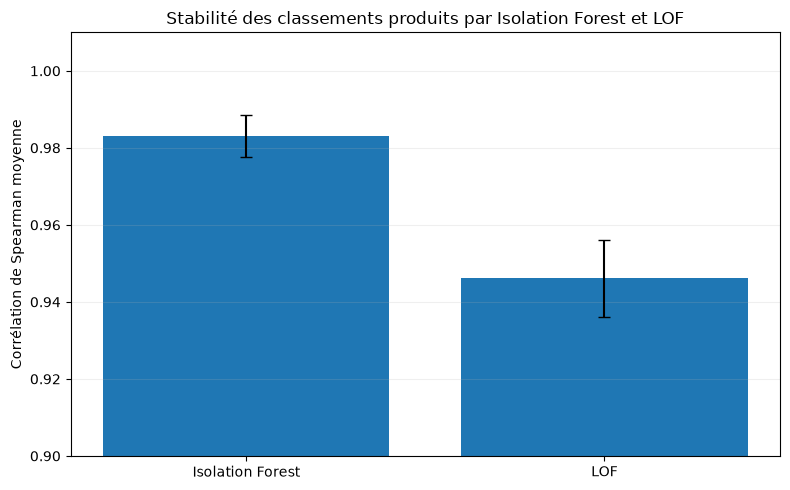

In [31]:
# =============================================================================
# Visuel Stabilité des classements produits par Isolation Forest et LOF
# =============================================================================
from pathlib import Path

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

stability_plot = stability_summary.copy()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    stability_plot["Methode"],
    stability_plot["Spearman_Moyenne"],
    yerr=stability_plot["Spearman_Ecart_Type"],
    capsize=4
)
ax.set_ylabel("Corrélation de Spearman moyenne")
ax.set_title(
    "Stabilité des classements produits par Isolation Forest et LOF"
)
ax.set_ylim(0.90, 1.01)
ax.grid(axis="y", alpha=0.20)
fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "stabilite_classements.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close(fig)


## Partie 8 — Sélection de la méthode ML

La sélection de la méthode ML repose principalement sur les performances obtenues lors de la validation sur les données synthétiques.

L'Average Precision constitue le critère principal, car elle exploite directement les scores continus d'atypie. La ROC-AUC est utilisée comme
métrique complémentaire.

Chaque configuration est évaluée sur l'ensemble du jeu de validation synthétique, en faisant varier les graines aléatoires, les niveaux de
perturbation et les scénarios.

Une analyse de stabilité des classements est ensuite réalisée séparément afin de vérifier la robustesse des résultats lorsque les conditions
d'apprentissage varient.


In [32]:
# =============================================================================
# COMPARAISON DES MÉTHODES
# =============================================================================
#
# La comparaison repose sur les performances moyennes obtenues sur l'ensemble
# des expériences de validation synthétique.
#
# L'Average Precision constitue le critère principal.
# La ROC-AUC apporte une mesure complémentaire de la capacité de classement.
#
# =============================================================================


final_method_comparison = (
    best_configurations[
        [
            "Methode",
            "Parametres",
            "Average_Precision_Moyenne",
            "Average_Precision_Ecart_Type",
            "ROC_AUC_Moyenne",
            "ROC_AUC_Ecart_Type"
        ]
    ]
    .merge(
        stability_summary[
            [
                "Methode",
                "Spearman_Moyenne",
                "Spearman_Ecart_Type"
            ]
        ],
        on="Methode",
        how="left"
    )
)


print("=" * 80)
print("COMPARAISON DES MEILLEURES CONFIGURATIONS")
print("=" * 80)

display(
    final_method_comparison.round(3)
)

COMPARAISON DES MEILLEURES CONFIGURATIONS


,Methode,Parametres,Average_Precision_Moyenne,Average_Precision_Ecart_Type,ROC_AUC_Moyenne,ROC_AUC_Ecart_Type,Spearman_Moyenne,Spearman_Ecart_Type
0,Isolation Forest,trees=300,0.250,0.031,0.817,0.027,0.983,0.005
1,LOF,neighbors=50,0.587,0.078,0.900,0.025,0.946,0.010


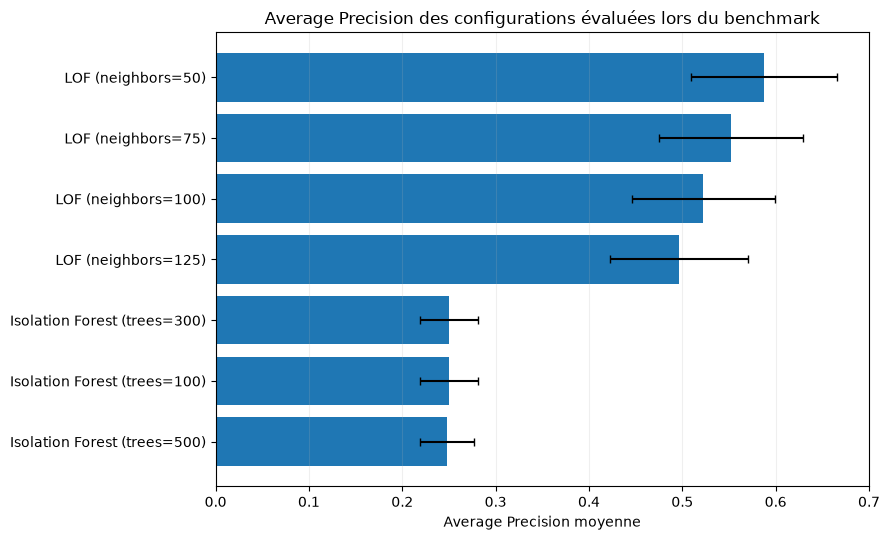

In [33]:
# =============================================================================
# Visuel Average Precision des configurations évaluées lors du benchmark
# =============================================================================

FIGURES_DIR = ANOMALY_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plot_data = summary_global.sort_values(
    "Average_Precision_Moyenne",
    ascending=True
).copy()

labels = [
    f"{row.Methode} ({row.Parametres})"
    for _, row in plot_data.iterrows()
]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(
    labels,
    plot_data["Average_Precision_Moyenne"],
    xerr=plot_data["Average_Precision_Ecart_Type"],
    capsize=3
)
ax.set_xlabel("Average Precision moyenne")
ax.set_title(
    "Average Precision des configurations évaluées lors du benchmark"
)
ax.set_xlim(0, 0.70)
ax.grid(axis="x", alpha=0.20)
fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "AP_benchmark.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close(fig)


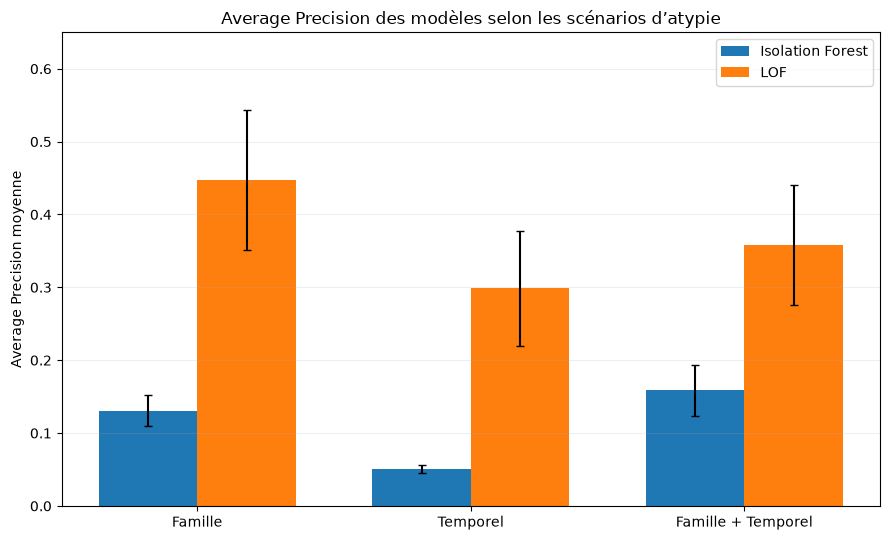

In [34]:
# =============================================================================
# Visuel Average Precision des modèles selon les scénarios d’atypie
# =============================================================================

scenario_plot = scenario_summary.copy()
scenario_order = ["Famille", "Temporel", "Famille + Temporel"]

fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(scenario_order))
width = 0.36

for j, method in enumerate(["Isolation Forest", "LOF"]):
    subset = (
        scenario_plot[scenario_plot["Methode"] == method]
        .set_index("Scenario")
        .reindex(scenario_order)
    )
    ax.bar(
        x + (j - 0.5) * width,
        subset["Average_Precision_Moyenne"],
        width,
        label=method,
        yerr=subset["Average_Precision_Ecart_Type"],
        capsize=3
    )

ax.set_xticks(x, scenario_order)
ax.set_ylabel("Average Precision moyenne")
ax.set_title(
    "Average Precision des modèles selon les scénarios d’atypie"
)
ax.set_ylim(0, 0.65)
ax.grid(axis="y", alpha=0.20)
ax.legend()
fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "AP_scenarios.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close(fig)


### Justification du choix du modèle ML

La comparaison des meilleures configurations montre une performance supérieure de LOF par rapport à Isolation Forest sur les données synthétiques de
validation.

La sélection repose principalement sur l'Average Precision, complétée par la ROC-AUC. Ces métriques sont calculées directement à partir des scores
continus d'atypie sur l'ensemble des observations de validation.

L'analyse de stabilité est réalisée séparément afin d'évaluer la robustesse des classements lorsque les conditions d'apprentissage varient. 

Au regard des résultats obtenus, la configuration LOF avec `n_neighbors = 50` est retenue comme modèle ML final.

Le modèle ML fournit ensuite un score continu d'atypie. La décision opérationnelle finale est réalisée sur les données réelles en distinguant
les règles métier, qui peuvent conduire directement à une anomalie critique, et le classement des scores ML, utilisé pour identifier les observations
à surveiller.

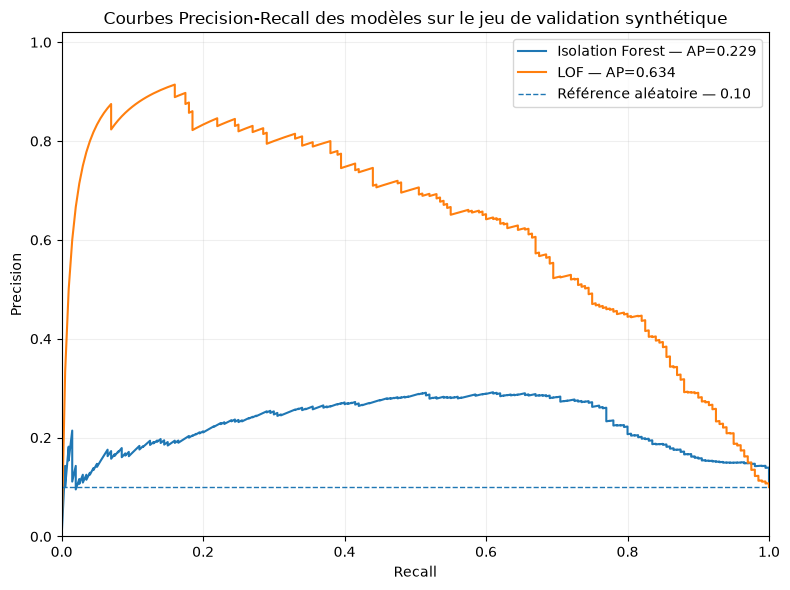

In [35]:
# =============================================================================
# Courbes Precision-Recall des modèles sur le jeu de validation
# synthétique
# =============================================================================
#
# Une expérience de référence est utilisée pour conserver un jeu identique
# entre les deux méthodes. Les meilleures configurations sont celles retenues
# sur l'ensemble du benchmark.
# =============================================================================

reference_seed = 42
reference_z = 3.5

reference_experiment = next(
    exp for exp in validation_experiments
    if exp["seed"] == reference_seed and exp["Z"] == reference_z
)

X_train_ref = reference_experiment["X_train"]
X_val_ref = reference_experiment["X_validation"]
y_val_ref = reference_experiment["y_validation"]

# Meilleure configuration Isolation Forest
best_if_row = best_configurations[
    best_configurations["Methode"] == "Isolation Forest"
].iloc[0]
best_if_trees = int(best_if_row["Parametres"].split("trees=")[1])

model_if_ref = IsolationForest(
    n_estimators=best_if_trees,
    contamination="auto",
    max_samples="auto",
    max_features=1.0,
    random_state=reference_seed,
    n_jobs=-1
)
model_if_ref.fit(X_train_ref)
scores_if_ref = isolation_forest_score(model_if_ref, X_val_ref)

# Meilleure configuration LOF
best_lof_row = best_configurations[
    best_configurations["Methode"] == "LOF"
].iloc[0]
best_lof_neighbors = int(best_lof_row["Parametres"].split("neighbors=")[1])

scaler_ref = RobustScaler()
X_train_lof_ref = scaler_ref.fit_transform(X_train_ref)
X_val_lof_ref = scaler_ref.transform(X_val_ref)

model_lof_ref = LocalOutlierFactor(
    n_neighbors=best_lof_neighbors,
    novelty=True,
    n_jobs=-1
)
model_lof_ref.fit(X_train_lof_ref)
scores_lof_ref = -model_lof_ref.score_samples(X_val_lof_ref)

precision_if, recall_if, _ = precision_recall_curve(y_val_ref, scores_if_ref)
precision_lof, recall_lof, _ = precision_recall_curve(y_val_ref, scores_lof_ref)

ap_if = average_precision_score(y_val_ref, scores_if_ref)
ap_lof = average_precision_score(y_val_ref, scores_lof_ref)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall_if, precision_if, label=f"Isolation Forest — AP={ap_if:.3f}")
ax.plot(recall_lof, precision_lof, label=f"LOF — AP={ap_lof:.3f}")
ax.axhline(
    y=float(y_val_ref.mean()),
    linestyle="--",
    linewidth=1,
    label=f"Référence aléatoire — {y_val_ref.mean():.2f}"
)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(
    "Courbes Precision-Recall des modèles sur le jeu de validation synthétique"
)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.20)
ax.legend()
fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "precision_recall.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close(fig)


In [36]:
# =============================================================================
# ENTRAÎNEMENT DU MODÈLE ML 
# =============================================================================
#
# Le benchmark synthétique a conduit à retenir :
# - méthode : LOF ;
# - n_neighbors : 50.
#
# =============================================================================


FINAL_METHOD = "LOF"

FINAL_N_NEIGHBORS = 50


# =============================================================================
# 1. Préparation des données
# =============================================================================

final_scaler = RobustScaler()


X_final_scaled = pd.DataFrame(
    final_scaler.fit_transform(
        X_anomaly_model
    ),
    columns=ml_features,
    index=X_anomaly_model.index
)


# =============================================================================
# 2. Entraînement LOF
# =============================================================================

final_model = LocalOutlierFactor(
    n_neighbors=FINAL_N_NEIGHBORS,
    novelty=False,
    n_jobs=-1
)


final_model.fit(
    X_final_scaled
)


# =============================================================================
# 3. Score continu d'atypie
# =============================================================================
#
# Plus le score est élevé, plus l'observation est atypique.
# =============================================================================

df_anomaly["ML_Anomaly_Score"] = (
    -final_model.negative_outlier_factor_
)


# =============================================================================
# 4. Classement des observations
# =============================================================================

df_anomaly["ML_Anomaly_Rank"] = (
    df_anomaly["ML_Anomaly_Score"]
    .rank(
        ascending=False,
        method="first"
    )
)


# =============================================================================
# 5. Vérifications
# =============================================================================

assert (
    df_anomaly["ML_Anomaly_Score"]
    .notna()
    .all()
)


assert (
    df_anomaly["ML_Anomaly_Rank"]
    .notna()
    .all()
)


# =============================================================================
# 6. Résumé
# =============================================================================

print("=" * 70)
print("MODÈLE ML FINAL")
print("=" * 70)

print(
    f"Méthode            : {FINAL_METHOD}"
)

print(
    f"n_neighbors         : {FINAL_N_NEIGHBORS}"
)

print(
    f"Variables ML        : {len(ml_features)}"
)

print(
    f"Observations        : {len(df_anomaly):,}"
)

print(
    f"Score ML moyen      : "
    f"{df_anomaly['ML_Anomaly_Score'].mean():.3f}"
)

print(
    f"Score ML minimum    : "
    f"{df_anomaly['ML_Anomaly_Score'].min():.3f}"
)

print(
    f"Score ML maximum    : "
    f"{df_anomaly['ML_Anomaly_Score'].max():.3f}"
)

MODÈLE ML FINAL
Méthode            : LOF
n_neighbors         : 50
Variables ML        : 14
Observations        : 68,324
Score ML moyen      : 1.218
Score ML minimum    : 0.952
Score ML maximum    : 264.411


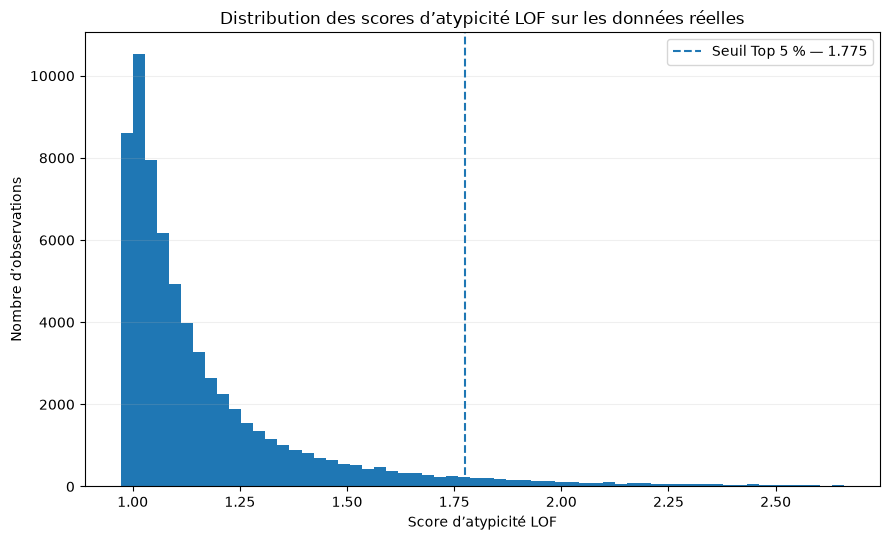

In [37]:
# =============================================================================
# Distribution des scores d’atypicité LOF sur les données réelles
# =============================================================================

threshold_top5 = df_anomaly["ML_Anomaly_Score"].quantile(0.95)

q01 = df_anomaly["ML_Anomaly_Score"].quantile(0.01)
q99 = df_anomaly["ML_Anomaly_Score"].quantile(0.99)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.hist(
    df_anomaly["ML_Anomaly_Score"].dropna(),
    bins=60,
    range=(q01, q99)
)
ax.axvline(
    threshold_top5,
    linestyle="--",
    linewidth=1.5,
    label=f"Seuil Top 5 % — {threshold_top5:.3f}"
)
ax.set_xlabel("Score d’atypicité LOF")
ax.set_ylabel("Nombre d’observations")
ax.set_title(
    "Distribution des scores d’atypicité LOF sur les données réelles"
)
ax.grid(axis="y", alpha=0.20)
ax.legend()
fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "distribution_scores_LOF.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close(fig)


## Partie 9 — Fusion des signaux d'anomalie

La décision finale ne repose pas sur un unique modèle.

Les signaux indépendants sont conservés séparément :

1. **Business** : incohérence économique explicite ;
2. **Peer / famille** : écart inhabituel parmi les EAN comparables ;
3. **Temporel** : rupture du comportement propre de l'EAN ;
4. **ML** : comportement multidimensionnel atypique.

La convergence de plusieurs signaux augmente la priorité de vérification, sans
transformer automatiquement le ML en vérité terrain.


In [38]:
# =============================================================================
# CONSOLIDATION DES INFORMATIONS DE DÉTECTION
# =============================================================================
#
# Les différents composants du pipeline conservent des rôles distincts :
#
# - Business_Rule_Anomaly : signal binaire issu des règles métier ;
# - Robust Z famille      : information de positionnement contextuel ;
# - Robust Z temporel     : information de rupture historique ;
# - ML_Anomaly_Score      : score continu d'atypie multidimensionnelle ;
# - ML_Top5pct            : appartenance au Top 5 % des scores ML.
#
# =============================================================================


# =============================================================================
# 1. Vérifications
# =============================================================================

assert (
    df_anomaly["Business_Rule_Anomaly"]
    .notna()
    .all()
)

assert (
    df_anomaly["ML_Anomaly_Score"]
    .notna()
    .all()
)

assert (
    df_anomaly["ML_Anomaly_Rank"]
    .notna()
    .all()
)


# =============================================================================
# 2. Classement ML sur l'ensemble des observations
# =============================================================================

ML_MONITORING_PERCENTAGE = 0.05

n_ml_monitoring = max(
    1,
    int(
        np.ceil(
            len(df_anomaly)
            * ML_MONITORING_PERCENTAGE
        )
    )
)

df_anomaly["ML_Top5pct"] = (
    df_anomaly["ML_Anomaly_Rank"]
    <= n_ml_monitoring
)


# =============================================================================
# 3. Signal de détection
# =============================================================================

def build_anomaly_signal(row):

    signals = []

    if bool(row["Business_Rule_Anomaly"]):
        signals.append("Règle métier")

    if bool(row["ML_Top5pct"]):
        signals.append("ML score")

    return (
        " | ".join(signals)
        if signals
        else "Aucun signal"
    )


df_anomaly["Anomaly_Signal"] = (
    df_anomaly.apply(
        build_anomaly_signal,
        axis=1
    )
)


# =============================================================================
# 4. Double signal : règle métier + Top 5 % ML
# =============================================================================

df_anomaly["Business_Rule_And_ML"] = (
    df_anomaly["Business_Rule_Anomaly"]
    & df_anomaly["ML_Top5pct"]
)


# =============================================================================
# 5. Résumé
# =============================================================================

print("=" * 70)
print("CONSOLIDATION DES INFORMATIONS DE DÉTECTION")
print("=" * 70)

print(
    f"Observations analysées : "
    f"{len(df_anomaly):,}"
)

print(
    f"Observations avec règle métier : "
    f"{int(df_anomaly['Business_Rule_Anomaly'].sum()):,}"
)

print(
    f"Top 5 % ML : "
    f"{n_ml_monitoring:,} observations"
)

print(
    f"Observations avec double signal "
    f"Règle métier + ML : "
    f"{int(df_anomaly['Business_Rule_And_ML'].sum()):,}"
)

display(
    df_anomaly[
        [
            "EAN",
            "ML_Anomaly_Score",
            "ML_Anomaly_Rank",
            "Business_Rule_Anomaly",
            "ML_Top5pct",
            "Anomaly_Signal",
            "Business_Rule_And_ML"
        ]
    ]
    .head(10)
)

CONSOLIDATION DES INFORMATIONS DE DÉTECTION
Observations analysées : 68,324
Observations avec règle métier : 1,663
Top 5 % ML : 3,417 observations
Observations avec double signal Règle métier + ML : 316


,EAN,ML_Anomaly_Score,ML_Anomaly_Rank,Business_Rule_Anomaly,ML_Top5pct,Anomaly_Signal,Business_Rule_And_ML
0,3014627554317,1.097077,31989.0,True,False,Règle métier,False
1,3014627554317,1.011052,54750.0,True,False,Règle métier,False
2,3014627554324,1.288898,13483.0,False,False,Aucun signal,False
3,3014627554324,1.131364,26683.0,False,False,Aucun signal,False
4,3014627554324,1.044596,43641.0,False,False,Aucun signal,False
5,3014627554324,1.041899,44413.0,False,False,Aucun signal,False
6,3014627554324,0.998790,59632.0,False,False,Aucun signal,False
7,3014627554324,2.988228,471.0,False,True,ML score,False
8,3014627554324,1.053592,41303.0,False,False,Aucun signal,False
9,3014627554324,1.103773,30861.0,False,False,Aucun signal,False


In [40]:
# =============================================================================
# PRÉPARATION DES RÉFÉRENCES HISTORIQUES POUR L'EXPLICABILITÉ
# =============================================================================

# -----------------------------------------------------------------------------
# Médianes historiques
# -----------------------------------------------------------------------------

df_anomaly["Temporal_Historical_Median_Selling_Price"] = (
    df_anomaly["EAN_Price_History_Median"]
)

df_anomaly["Temporal_Historical_Median_Purchase_Price"] = (
    df_anomaly["EAN_Purchase_Price_History_Median"]
)

df_anomaly["Temporal_Historical_Median_Margin_MDH"] = (
    df_anomaly["EAN_Margin_History_Median"]
)

df_anomaly["Temporal_Historical_Median_Margin_Local"] = (
    df_anomaly["EAN_Margin_Local_History_Median"]
)


# -----------------------------------------------------------------------------
# Écarts absolus par rapport à la médiane historique
# -----------------------------------------------------------------------------


df_anomaly["Temporal_Absolute_Deviation_Selling_Price"] = (
    (
        df_anomaly["Average selling price N"]
        - df_anomaly["Temporal_Historical_Median_Selling_Price"]
    )
    .abs()
)

df_anomaly["Temporal_Absolute_Deviation_Purchase_Price"] = (
    (
        df_anomaly["Average Purchasing Price N"]
        - df_anomaly["Temporal_Historical_Median_Purchase_Price"]
    )
    .abs()
)

df_anomaly["Temporal_Absolute_Deviation_Margin_MDH"] = (
    (
        df_anomaly["Tx M3N MDH Inter N"]
        - df_anomaly["Temporal_Historical_Median_Margin_MDH"]
    )
    .abs()
)

df_anomaly["Temporal_Absolute_Deviation_Margin_Local"] = (
    (
        df_anomaly["Tx M3N non CP N"]
        - df_anomaly["Temporal_Historical_Median_Margin_Local"]
    )
    .abs()
)


# -----------------------------------------------------------------------------
# Contrôle
# -----------------------------------------------------------------------------

temporal_explanatory_columns = [
    "Temporal_Historical_Median_Selling_Price",
    "Temporal_Historical_Median_Purchase_Price",
    "Temporal_Historical_Median_Margin_MDH",
    "Temporal_Historical_Median_Margin_Local",
    "Temporal_Absolute_Deviation_Selling_Price",
    "Temporal_Absolute_Deviation_Purchase_Price",
    "Temporal_Absolute_Deviation_Margin_MDH",
    "Temporal_Absolute_Deviation_Margin_Local"
]

missing_temporal_explanatory = [
    col
    for col in temporal_explanatory_columns
    if col not in df_anomaly.columns
]

if missing_temporal_explanatory:
    raise ValueError(
        "Colonnes d'explicabilité temporelle absentes : "
        + ", ".join(missing_temporal_explanatory)
    )

print("=" * 70)
print("RÉFÉRENCES HISTORIQUES POUR L'EXPLICABILITÉ")
print("=" * 70)

print(
    f"Nombre de variables d'explicabilité temporelle : "
    f"{len(temporal_explanatory_columns)}"
)

print("Les références historiques sont disponibles.")

RÉFÉRENCES HISTORIQUES POUR L'EXPLICABILITÉ
Nombre de variables d'explicabilité temporelle : 8
Les références historiques sont disponibles.


In [41]:
# =============================================================================
# RAISON DE L'ANOMALIE
# =============================================================================



DISPLAY_NAMES = {
    "Selling_Price": "prix de vente",
    "Purchase_Price": "prix d'achat",
    "Margin_MDH": "marge internationale",
    "Margin_Local": "marge locale"
}


VALUE_COLUMNS = {
    "Selling_Price": "Average selling price N",
    "Purchase_Price": "Average Purchasing Price N",
    "Margin_MDH": "Tx M3N MDH Inter N",
    "Margin_Local": "Tx M3N non CP N"
}


def format_value(value):

    if pd.isna(value):
        return None

    return f"{value:.2f}"


def build_anomaly_reason(row):

    reasons = []


    # =========================================================================
    # 1. RÈGLE MÉTIER
    # =========================================================================

    has_business_rule = bool(
        row["Business_Rule_Anomaly"]
    )

    has_ml_signal = bool(
        row["ML_Top5pct"]
    )


    if has_business_rule:

        business_reason = row.get(
            "Business_Rule_Reason"
        )

        if (
            pd.notna(business_reason)
            and str(business_reason).strip() != ""
        ):

            reasons.append(
                f"Règle métier : {business_reason}"
            )

        else:

            reasons.append(
                "Règle métier : violation d'une règle métier"
            )


    # =========================================================================
    # 2. CONTEXTE FAMILLE ET HISTORIQUE
    # =========================================================================

    if has_ml_signal:


        # =====================================================================
        # 2.1 COMPORTEMENT INTRA-FAMILLE
        # =====================================================================

        family_variables = {

            "Selling_Price": (
                "Family_Robust_Z_Selling_Price",
                "Family_Median_Selling_Price"
            ),

            "Purchase_Price": (
                "Family_Robust_Z_Purchase_Price",
                "Family_Median_Purchase_Price"
            ),

            "Margin_MDH": (
                "Family_Robust_Z_Margin_MDH",
                "Family_Median_Margin"
            ),

            "Margin_Local": (
                "Family_Robust_Z_Margin_Local",
                "Family_Median_Margin_Local"
            )
        }


        family_messages = []


        for name, (
            z_column,
            median_column
        ) in family_variables.items():


            if z_column not in row.index:
                continue


            if pd.isna(row[z_column]):
                continue


            value_column = VALUE_COLUMNS[name]


            if value_column not in row.index:
                continue


            current_value = row[value_column]


            family_median = row.get(
                median_column
            )


            if (
                pd.notna(current_value)
                and pd.notna(family_median)
            ):

                deviation = abs(
                    current_value
                    - family_median
                )


                family_messages.append(

                    f"{DISPLAY_NAMES[name]} "
                    f"{format_value(current_value)} "
                    f"contre "
                    f"{format_value(family_median)} "
                    f"habituellement dans la famille "
                    f"(écart "
                    f"{format_value(deviation)})"
                )


        if family_messages:

            reasons.append(

                "Comportement intra-famille : "
                + " ; ".join(family_messages)
            )


        # =====================================================================
        # 2.2 RUPTURE HISTORIQUE
        # =====================================================================

        temporal_variables = {

            "Selling_Price": (
                "Temporal_Robust_Z_Selling_Price",
                "Temporal_Historical_Median_Selling_Price",
                "Temporal_Absolute_Deviation_Selling_Price"
            ),

            "Purchase_Price": (
                "Temporal_Robust_Z_Purchase_Price",
                "Temporal_Historical_Median_Purchase_Price",
                "Temporal_Absolute_Deviation_Purchase_Price"
            ),

            "Margin_MDH": (
                "Temporal_Robust_Z_Margin_MDH",
                "Temporal_Historical_Median_Margin_MDH",
                "Temporal_Absolute_Deviation_Margin_MDH"
            ),

            "Margin_Local": (
                "Temporal_Robust_Z_Margin_Local",
                "Temporal_Historical_Median_Margin_Local",
                "Temporal_Absolute_Deviation_Margin_Local"
            )
        }


        temporal_messages = []


        for name, (
            z_column,
            median_column,
            deviation_column
        ) in temporal_variables.items():


            if z_column not in row.index:
                continue


            if pd.isna(row[z_column]):
                continue


            value_column = VALUE_COLUMNS[name]


            if value_column not in row.index:
                continue


            current_value = row[value_column]


            historical_median = row.get(
                median_column
            )


            if (
                pd.notna(current_value)
                and pd.notna(historical_median)
            ):

                deviation = row.get(
                    deviation_column
                )


                if pd.isna(deviation):

                    deviation = abs(
                        current_value
                        - historical_median
                    )


                temporal_messages.append(

                    f"{DISPLAY_NAMES[name]} "
                    f"{format_value(current_value)} "
                    f"contre "
                    f"{format_value(historical_median)} "
                    f"habituellement pour cet EAN "
                    f"(écart "
                    f"{format_value(abs(deviation))})"
                )


        if temporal_messages:

            reasons.append(

                "Rupture historique : "
                + " ; ".join(temporal_messages)
            )


    # =========================================================================
    # 3. RÉSULTAT
    # =========================================================================

    return (

        " | ".join(reasons)

        if reasons

        else "Aucune information explicative disponible"
    )


df_anomaly["Anomaly_Reason"] = (
    df_anomaly.apply(
        build_anomaly_reason,
        axis=1
    )
)

In [42]:
# =============================================================================
# PRIORISATION OPÉRATIONNELLE
# =============================================================================
#
# La priorisation est réalisée sur les données réelles après calcul
# du score ML du modèle final.
#
# Règle de décision :
#
# 1. Violation d'une règle métier -> Critique
# 2. Pas de règle + Top 5 % ML   -> À surveiller
# 3. Sinon                       -> Normal
#
# =============================================================================


ML_MONITORING_PERCENTAGE = 0.05


# =============================================================================
# 1. Top 5 % ML
# =============================================================================

n_ml_monitoring = max(
    1,
    int(
        np.ceil(
            len(df_anomaly)
            * ML_MONITORING_PERCENTAGE
        )
    )
)


df_anomaly["ML_Top5pct"] = (
    df_anomaly["ML_Anomaly_Rank"]
    <= n_ml_monitoring
)


# =============================================================================
# 2. Priorité finale
# =============================================================================

df_anomaly["Anomaly_Priority"] = np.select(
    [
        df_anomaly["Business_Rule_Anomaly"],
        df_anomaly["ML_Top5pct"]
    ],
    [
        "Critique",
        "À surveiller"
    ],
    default="Normal"
)


# =============================================================================
# 3. Double signal
# =============================================================================

df_anomaly["Business_Rule_And_ML"] = (
    df_anomaly["Business_Rule_Anomaly"]
    &
    df_anomaly["ML_Top5pct"]
)


# =============================================================================
# 4. Résumé
# =============================================================================

priority_summary = (
    df_anomaly["Anomaly_Priority"]
    .value_counts()
    .rename_axis("Priorite")
    .reset_index(
        name="Nombre"
    )
)

priority_summary["Pourcentage"] = (
    priority_summary["Nombre"]
    / len(df_anomaly)
    * 100
).round(2)


print("=" * 70)
print("PRIORISATION OPÉRATIONNELLE")
print("=" * 70)

print(
    f"Part du Top ML : "
    f"{ML_MONITORING_PERCENTAGE:.1%}"
)

print(
    f"Nombre d'observations dans le Top 5 % ML : "
    f"{n_ml_monitoring:,}"
)

print(
    f"Observations Critiques : "
    f"{int((df_anomaly['Anomaly_Priority'] == 'Critique').sum()):,}"
)

print(
    f"Observations À surveiller : "
    f"{int((df_anomaly['Anomaly_Priority'] == 'À surveiller').sum()):,}"
)

print(
    f"Observations avec double signal "
    f"Règle métier + ML : "
    f"{int(df_anomaly['Business_Rule_And_ML'].sum()):,}"
)

display(priority_summary)

PRIORISATION OPÉRATIONNELLE
Part du Top ML : 5.0%
Nombre d'observations dans le Top 5 % ML : 3,417
Observations Critiques : 1,663
Observations À surveiller : 3,101
Observations avec double signal Règle métier + ML : 316


,Priorite,Nombre,Pourcentage
0,Normal,63560,93.03
1,À surveiller,3101,4.54
2,Critique,1663,2.43


In [43]:
# =============================================================================
# CONTRÔLES DE COHÉRENCE
# =============================================================================

print("=" * 70)
print("CONTRÔLES DE COHÉRENCE")
print("=" * 70)


# =============================================================================
# 1. Le score ML existe pour toutes les observations
# =============================================================================

if not df_anomaly["ML_Anomaly_Score"].notna().all():

    raise ValueError(
        "Certains scores ML sont manquants."
    )


# =============================================================================
# 2. Le rang ML existe pour toutes les observations
# =============================================================================

if not df_anomaly["ML_Anomaly_Rank"].notna().all():

    raise ValueError(
        "Certains rangs ML sont manquants."
    )


# =============================================================================
# 3. Le Top 5 % est cohérent avec le rang ML
# =============================================================================

expected_ml_top5 = (
    df_anomaly["ML_Anomaly_Rank"]
    <= n_ml_monitoring
)

if not (
    df_anomaly["ML_Top5pct"]
    == expected_ml_top5
).all():

    raise ValueError(
        "Incohérence dans le calcul du Top 5 % ML."
    )


# =============================================================================
# 4. La priorité respecte la règle métier
# =============================================================================

critical_consistency = (
    df_anomaly.loc[
        df_anomaly["Business_Rule_Anomaly"],
        "Anomaly_Priority"
    ]
    == "Critique"
).all()


if not critical_consistency:

    raise ValueError(
        "Une observation avec violation métier "
        "n'est pas classée Critique."
    )


# =============================================================================
# 5. Le ML seul produit À surveiller
# =============================================================================

monitoring_consistency = (
    df_anomaly.loc[
        (
            ~df_anomaly["Business_Rule_Anomaly"]
            &
            df_anomaly["ML_Top5pct"]
        ),
        "Anomaly_Priority"
    ]
    == "À surveiller"
).all()


if not monitoring_consistency:

    raise ValueError(
        "Incohérence dans la priorité À surveiller."
    )


# =============================================================================
# 6. Vérification du double signal
# =============================================================================

expected_double_signal = (
    df_anomaly["Business_Rule_Anomaly"]
    &
    df_anomaly["ML_Top5pct"]
)

if not (
    df_anomaly["Business_Rule_And_ML"]
    == expected_double_signal
).all():

    raise ValueError(
        "Incohérence dans le double signal."
    )


print("Tous les contrôles de cohérence : OK")


display(
    pd.crosstab(
        df_anomaly["Anomaly_Signal"],
        df_anomaly["Anomaly_Priority"]
    )
)

CONTRÔLES DE COHÉRENCE
Tous les contrôles de cohérence : OK


Anomaly_Priority,Critique,Normal,À surveiller
Anomaly_Signal,,,
Aucun signal,0,63560,0
ML score,0,0,3101
Règle métier,1347,0,0
Règle métier | ML score,316,0,0


# Partie 10 — Table de restitution

La table finale conserve les informations nécessaires au métier et à Power BI :
dimensions produit/période, prix, marges, évolutions, contexte famille et
résultats explicables de détection.

Les variables purement techniques du modèle ne sont pas toutes exposées.


In [44]:
# =============================================================================
# Sélection des champs utiles à la restitution métier
# =============================================================================

bi_columns = [
    # Dimensions
    "Year",
    "MonthLib",
    "International Department",
    "International Sub Department",
    "International Family",
    "EAN",
    "Offer_Type",

    # Economique N / N-1
    "Tx M3N MDH Inter N",
    "Tx M3N non CP N",
    "Tx M3N MDH Inter N-1",
    "Tx M3N non CP N-1",
    "Average Purchasing Price N",
    "Average selling price N",
    "Average Purchasing Price N-1",
    "Average Selling Price N-1",

    # Evolutions / indicateurs
    "Price_Gap_N",
    "Price_Ratio_N",
    "Purchase_Price_Delta",
    "Selling_Price_Delta",
    "Purchase_Price_Variation",
    "Selling_Price_Variation",
    "Margin_MDH_Delta",
    "Margin_Local_Delta",
    "Margin_MDH_Variation",
    "Margin_Local_Variation",

    # Contexte famille
    "Family_Median_Selling_Price",
    "Family_Median_Purchase_Price",
    "Selling_Price_vs_Family",
    "Purchase_Price_vs_Family",
    "Family_Median_Margin",
    "Margin_vs_Family",
    "Family_Median_Margin_Local",
    "Margin_Local_vs_Family",

    # Signaux et explicabilité
    "Business_Rule_Anomaly",
    "Business_Rule_Reason",

    "ML_Anomaly_Score",
    "ML_Anomaly_Rank",
    "ML_Top5pct",

    "Anomaly_Signal",
    "Business_Rule_And_ML",

    "Anomaly_Type",
    "Anomaly_Reason",
    "Anomaly_Priority",

    # Références historiques pour l'explicabilité temporelle
    
    "Temporal_Historical_Median_Selling_Price",
    "Temporal_Historical_Median_Purchase_Price",
    "Temporal_Historical_Median_Margin_MDH",
    "Temporal_Historical_Median_Margin_Local",

    "Temporal_Absolute_Deviation_Selling_Price",
    "Temporal_Absolute_Deviation_Purchase_Price",
    "Temporal_Absolute_Deviation_Margin_MDH",
    "Temporal_Absolute_Deviation_Margin_Local",

    "Family_Robust_Z_Selling_Price",
    "Family_Robust_Z_Purchase_Price",
    "Family_Robust_Z_Margin_MDH",
    "Family_Robust_Z_Margin_Local"
    ]


bi_columns_available = [
    col for col in bi_columns
    if col in df_anomaly.columns
]

df_anomaly_bi = df_anomaly[
    bi_columns_available
].copy()

print("=" * 70)
print("TABLE POWER BI")
print("=" * 70)

print(f"Lignes   : {len(df_anomaly_bi):,}")
print(f"Colonnes : {df_anomaly_bi.shape[1]:,}")


TABLE POWER BI
Lignes   : 68,324
Colonnes : 49


In [45]:
# =============================================================================
# SYNTHÈSE FINALE DU PIPELINE
# =============================================================================

total_observations = len(df_anomaly_bi)

total_critical = int(
    (
        df_anomaly_bi["Anomaly_Priority"]
        == "Critique"
    ).sum()
)

total_monitoring = int(
    (
        df_anomaly_bi["Anomaly_Priority"]
        == "À surveiller"
    ).sum()
)

total_normal = int(
    (
        df_anomaly_bi["Anomaly_Priority"]
        == "Normal"
    ).sum()
)

total_business_rules = int(
    df_anomaly_bi[
        "Business_Rule_Anomaly"
    ].sum()
)

total_ml_top5 = int(
    df_anomaly_bi[
        "ML_Top5pct"
    ].sum()
)

total_double_signal = int(
    df_anomaly_bi[
        "Business_Rule_And_ML"
    ].sum()
)


print("=" * 70)
print("SYNTHESE FINALE - DETECTION CONTEXTUALISEE")
print("=" * 70)

print(
    f"Observations analysées       : "
    f"{total_observations:,}"
)

print(
    f"Règles métier               : "
    f"{total_business_rules:,}"
)

print(
    f"Top 5 % ML                  : "
    f"{total_ml_top5:,}"
)

print(
    f"Double signal Règle + ML   : "
    f"{total_double_signal:,}"
)

print(
    f"Priorité critique           : "
    f"{total_critical:,}"
)

print(
    f"À surveiller                : "
    f"{total_monitoring:,}"
)

print(
    f"Normal                      : "
    f"{total_normal:,}"
)

print()

print(
    f"Modèle ML final             : "
    f"{FINAL_METHOD}"
)

print(
    f"n_neighbors                 : "
    f"{FINAL_N_NEIGHBORS}"
)

print(
    f"Part du monitoring ML       : "
    f"{ML_MONITORING_PERCENTAGE:.1%}"
)

print(
    f"Taux Critique               : "
    f"{total_critical / total_observations:.2%}"
)

print(
    f"Taux À surveiller           : "
    f"{total_monitoring / total_observations:.2%}"
)

print(
    f"Taux Normal                 : "
    f"{total_normal / total_observations:.2%}"
)

SYNTHESE FINALE - DETECTION CONTEXTUALISEE
Observations analysées       : 68,324
Règles métier               : 1,663
Top 5 % ML                  : 3,417
Double signal Règle + ML   : 316
Priorité critique           : 1,663
À surveiller                : 3,101
Normal                      : 63,560

Modèle ML final             : LOF
n_neighbors                 : 50
Part du monitoring ML       : 5.0%
Taux Critique               : 2.43%
Taux À surveiller           : 4.54%
Taux Normal                 : 93.03%


In [46]:
# =============================================================================
# Export du dataset pour Power BI
# =============================================================================

POWERBI_PATH = (
    ANOMALY_DIR
    / "anomaly_detection_powerbi.csv"
)

df_anomaly_bi.to_csv(
    POWERBI_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("=" * 70)
print("EXPORT FINAL")
print("=" * 70)

print(f"Fichier Power BI : {POWERBI_PATH}")
print(f"Lignes           : {len(df_anomaly_bi):,}")
print(f"Colonnes         : {df_anomaly_bi.shape[1]:,}")


EXPORT FINAL
Fichier Power BI : C:\Users\20017459\Documents\Algo_3NM\data\results\anomaly_detection\anomaly_detection_powerbi.csv
Lignes           : 68,324
Colonnes         : 49
